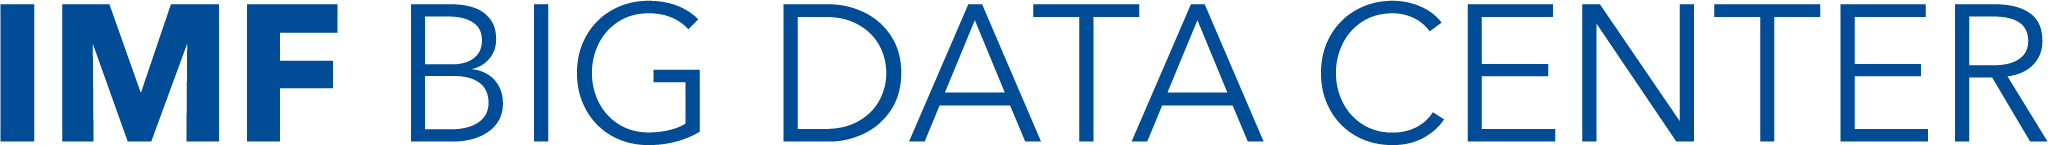

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AlessandraSozzi/BDC_STI_26/blob/main/notebooks/BDC_GoogleTrends_explore.ipynb)

# Google Trends Explore

---

<br>**Contributors:**
<br> **Last update:**
<br> **Description:** This notebook queries the Google Trends API to retrieve the search volume index and rising topics for a given term and country, and plots the resulting series
<br> **References:**

In [ ]:
!pip install google-api-python-client

   ---------------------------------------- 0.0/12.2 MB ? eta -:--:--
    --------------------------------------- 0.2/12.2 MB 4.1 MB/s eta 0:00:03
   - -------------------------------------- 0.5/12.2 MB 4.8 MB/s eta 0:00:03
   --- ------------------------------------ 0.9/12.2 MB 6.6 MB/s eta 0:00:02
   -------- ------------------------------- 2.5/12.2 MB 13.4 MB/s eta 0:00:01
   ------------- -------------------------- 4.0/12.2 MB 18.4 MB/s eta 0:00:01
   ----------------- ---------------------- 5.4/12.2 MB 20.3 MB/s eta 0:00:01
   ------------------ --------------------- 5.6/12.2 MB 17.8 MB/s eta 0:00:01
   ------------------------ --------------- 7.5/12.2 MB 20.9 MB/s eta 0:00:01
   ------------------------------- -------- 9.5/12.2 MB 23.5 MB/s eta 0:00:01
   ------------------------------------ --- 11.1/12.2 MB 31.2 MB/s eta 0:00:01
   ---------------------------------------  12.2/12.2 MB 32.8 MB/s eta 0:00:01
   ---------------------------------------- 12.2/12.2 MB 28.5 MB/s eta 0:


[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import json
import os

import matplotlib.pyplot as plt
import pandas as pd
import requests

from googleapiclient.discovery import build
from matplotlib.dates import DateFormatter

In [ ]:
API_KEY = 'PUT YOUR API KEY HERE'
os.environ['GOOGLE_TOKEN'] = API_KEY

In [ ]:
class Google():
    """
    Wrapper class for handling authentication and requests (GET) to Google API

    Parameters
    ----------
    token : str
        Google API token

    Notes
    -----
    For more information, please see https://developers.google.com/apis-explorer
    """

    def __init__(self, token=None):
        self.TOKEN = token if token else os.getenv("GOOGLE_TOKEN")

    @property
    def service(self):
        """Authenticate and instantiate Google API service"""
        return build('trends', 'v1beta', static_discovery=False, developerKey=self.TOKEN)

    def get(self, method, params):
        """Get result from Google API method"""
        return getattr(self.service, method)(**params).execute()


    def download(self, method, params):
        """Download result from Google API method"""

        if not method in ["getGraph", "getTimelinesForHealth"]:
            raise NotImplementedError("Method not supported.")

        result = self.get(method, params)

        df = pd.json_normalize(result["lines"], meta=["term"], record_path=["points"])

        params = "+".join([f"{k}={v}" for k, v in params.items()])
        name = f"{method}+{params}.csv"

        df.to_csv(name, index=False)

In [ ]:
google = Google()

#### SVI for a term

In [ ]:
filter_unemployment = {
    'terms': ['unemployment'],
    'restrictions_geo': 'US',
    'restrictions_startDate': '2004-01'
}

In [ ]:
r = google.get('getGraph', filter_unemployment)

df = pd.DataFrame(r["lines"][0]["points"])
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")

df.to_excel('unemployment_US_GT.xlsx')

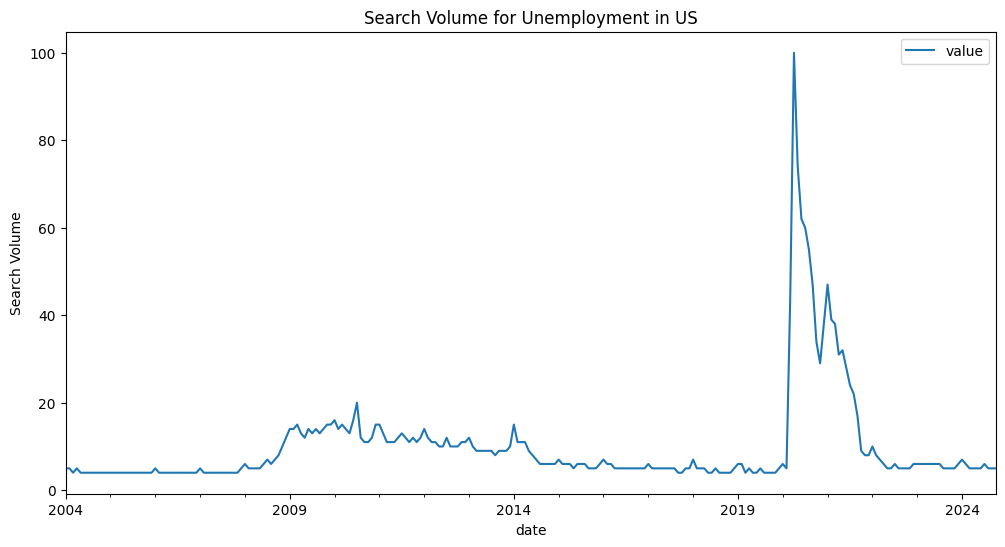

In [ ]:
ax = df.plot(figsize=(12, 6))
ax.set_ylabel('Search Volume')
ax.set_title('Search Volume for Unemployment in US');

#### Rising topics

In [ ]:
filter_rising_topics = {
    'term':'unemployment',
    'restrictions_geo': 'US',
    'restrictions_startDate' : '2024-09'
}

r_topics=google.get('getRisingTopics', filter_rising_topics)

In [ ]:
df_topics = pd.DataFrame(r_topics['item'])
df_topics.to_excel('rising topics.xlsx')

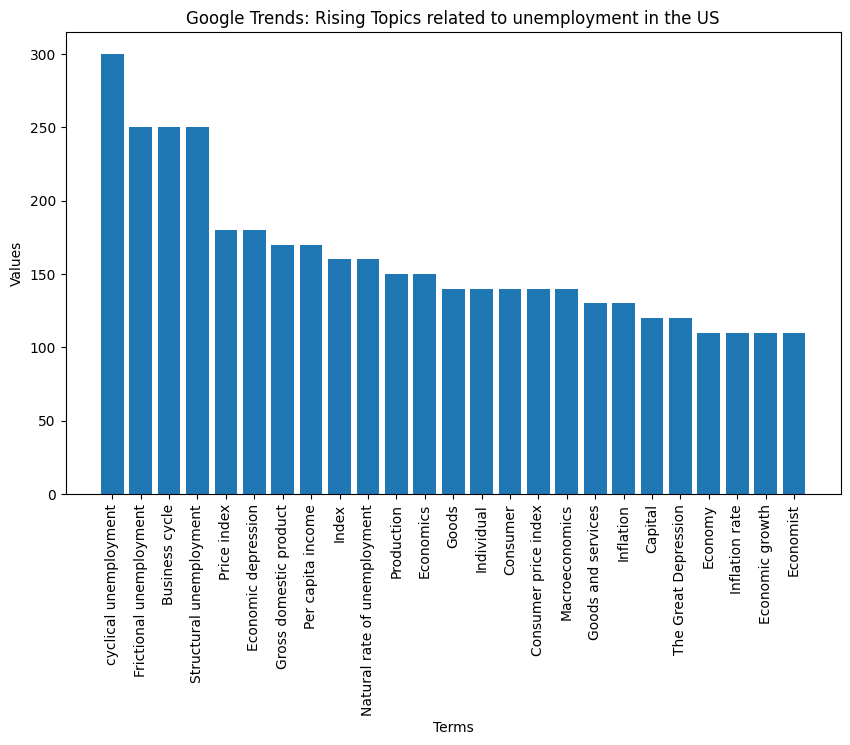

In [ ]:
df = pd.DataFrame(r_topics['item'])
plt.figure(figsize=(10, 6))
plt.title('Google Trends: Rising Topics related to unemployment in the US')
plt.xlabel('Terms')
plt.ylabel('Values')
plt.xticks(rotation=90)

plt.bar(df['title'], df['value']);